# Countdown distillation on Gemma 3 1B

`google/gemma-3-1b-it` is a compact student model and is a good fit for distillation. Here we follow the idea of the Kaggle `distillation-challenge-2026` competition to train this small LLM play Countdown: using a given set of numbers and basic operators (`+`, `-`, `*`, `/`), create an equation that hits a specific target number. Example:

* Numbers: `[75, 80, 90, 24]`
* Target: `61`
* Solution: `90 - 80 + 75 - 24 = 61`

We use verified Qwen3-4B answers from Hugging Face as supervision, so the student learns directly from traces in text and `<answer>` format.

## Installation

The package set stays close to the training loop used in the Gemma notebook style, with TRL for SFT, PEFT for LoRA, and the Hugging Face stack for data handling.


In [ ]:
!pip install -U transformers accelerate peft trl datasets huggingface-hub pandas matplotlib torch

## Imports and configuration

In [26]:
import os
import re
import json
import random
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tqdm.auto import tqdm
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainerCallback
from huggingface_hub import login
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig

login("YOUR_TOKEN")
hf_dataset_id = "HuggingFaceTB/Countdown-Task-GOLD"
verified_split_id = "verified_Qwen3-4B-Instruct-2507"
student_model_id = "google/gemma-3-1b-it"

output_dir = "./gemma3_1b_countdown_verified_10k"
submission_path = "./submission.csv"
hub_model_id = "pymlex/gemma3-1b-countdown"

seed = 3407
train_limit = float('inf')

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
fp16 = torch.cuda.is_available() and not bf16

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
vram_gb = 0.0

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / (1024 ** 3)

print(f"GPU: {device_name}")
print(f"VRAM: {vram_gb:.2f} GB")
print(f"bf16: {bf16}")
print(f"fp16: {fp16}")

GPU: NVIDIA GeForce RTX 5090
VRAM: 31.32 GB
bf16: True
fp16: False


## Dataset 

In [2]:
dataset = load_dataset(hf_dataset_id, verified_split_id)
train_base = dataset["train"]

train_base = train_base.shuffle(seed=seed)
train_base = train_base.select(range(min(train_limit, len(train_base))))

print(train_base)
print(train_base.column_names)
print(train_base[0])

README.md: 0.00B [00:00, ?B/s]

verified_Qwen3-4B-Instruct-2507/train-00(…):   0%|          | 0.00/15.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/27667 [00:00<?, ? examples/s]

Dataset({
    features: ['target', 'nums', 'messages'],
    num_rows: 27667
})
['target', 'nums', 'messages']
{'target': 49, 'nums': [24, 2, 74], 'messages': [{'content': 'You are a helpful assistant. You first think about the reasoning process in the mind and then provide the user with the answer.', 'role': 'system'}, {'content': 'Using the numbers [24, 2, 74], create an equation that equals 49. You can use basic arithmetic operations (+, -, *, /) and each number can only be used once. Show your work in <think> </think> tags. And return the final equation and answer in <answer> </answer> tags, for example <answer> (1 + 2) / 3 = 1 </answer>.', 'role': 'user'}, {'content': "Let's analyze the numbers given: [24, 2, 74]. We need to use each number exactly once and combine them with basic arithmetic operations (+, −, ×, ÷) to get 49.\n\nWe are trying to reach 49.\n\nLet’s explore possible combinations.\n\nFirst, note that 74 is quite large. If we subtract something from 74, we might get cl

## Text building and length histogram

In [4]:
from tqdm.auto import tqdm

student_tokenizer = AutoTokenizer.from_pretrained(student_model_id)
if student_tokenizer.pad_token is None:
    student_tokenizer.pad_token = student_tokenizer.eos_token
student_tokenizer.padding_side = "right"

def make_student_text(example, tokenizer):
    return tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False
    )

student_rows = []

for example in train_base:
    text = make_student_text(example, student_tokenizer)
    student_rows.append({
        "text": text
    })

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

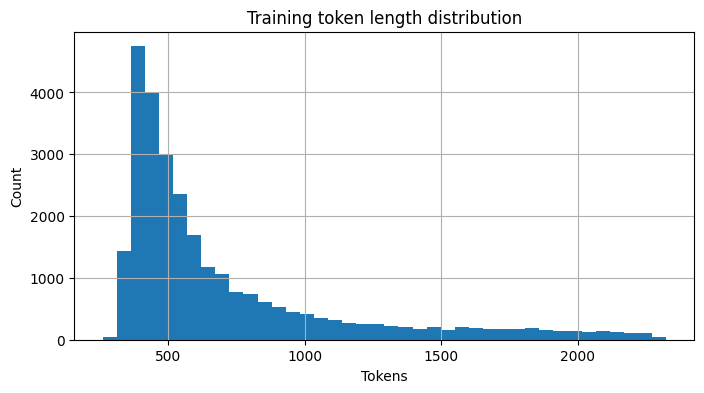

In [5]:
student_df = pd.DataFrame(student_rows)
student_df["char_len"] = student_df["text"].str.len()
student_df["token_len"] = student_df["text"].apply(
    lambda x: len(student_tokenizer(x, add_special_tokens=False)["input_ids"])
)

plt.figure(figsize=(8, 4))
plt.hist(student_df["token_len"], bins=40)
plt.title("Training token length distribution")
plt.xlabel("Tokens")
plt.ylabel("Count")
plt.grid(True)
plt.show()

We set `max_seq_length` to 1024 to use less VRAM. Only the examples that are shorter than 850 are left because prompts from the dataset are approximately 130 symbols long, so the model can output no more than ~850 tokens.

In [6]:
print(student_df["token_len"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))
max_seq_length = 1024
student_df = student_df[student_df["token_len"] < 850].reset_index(drop=True)
print(f"Selected max_seq_length = {max_seq_length}")

count    27667.000000
mean       708.680920
std        434.486194
min        260.000000
50%        530.000000
75%        808.000000
90%       1392.400000
95%       1770.000000
99%       2163.000000
max       2324.000000
Name: token_len, dtype: float64
Selected max_seq_length = 1024


## Train / validation split

In [7]:
dataset_all = Dataset.from_pandas(student_df[["text"]], preserve_index=False)
split_1 = dataset_all.train_test_split(test_size=0.05, seed=seed)

train_ds = split_1["train"]
val_ds = split_1["test"]

print(train_ds)
print(val_ds)

Dataset({
    features: ['text'],
    num_rows: 20216
})
Dataset({
    features: ['text'],
    num_rows: 1064
})


In [31]:
train_ds[0]

{'text': "<bos><start_of_turn>user\nYou are a helpful assistant. You first think about the reasoning process in the mind and then provide the user with the answer.\n\nUsing the numbers [16, 26, 12, 43], create an equation that equals 97. You can use basic arithmetic operations (+, -, *, /) and each number can only be used once. Show your work in <think> </think> tags. And return the final equation and answer in <answer> </answer> tags, for example <answer> (1 + 2) / 3 = 1 </answer>.<end_of_turn>\n<start_of_turn>model\nLet's think step by step.\n\nWe are given the numbers: [16, 26, 12, 43]  \nWe need to use each number **exactly once** and use basic arithmetic operations (+, -, *, /) to make an expression that equals **97**.\n\nWe are to find a combination of operations that results in 97.\n\nLet’s try to estimate:\n\nTry adding some of the larger numbers:\n- 43 + 26 = 69\n- 69 + 16 = 85 → 85 + 12 = 97 → that’s interesting!\n\nWait: 43 + 26 = 69  \n69 + 16 = 85  \n85 + 12 = 97\n\nSo: 43

## Base model, LoRA, and training config

The model is loaded in bf16 when possible. We also use a GPU callback to monitor system resources.

In [8]:
student_model = AutoModelForCausalLM.from_pretrained(
    student_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if bf16 else torch.float16
)

student_model.config.use_cache = False
student_model.gradient_checkpointing_enable()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

In [9]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ]
)

def gpu_status_line():
    if not torch.cuda.is_available():
        return "GPU=cpu"

    device_id = torch.cuda.current_device()
    raw = subprocess.check_output([
        "nvidia-smi",
        "--query-gpu=utilization.gpu,memory.used,memory.total",
        "--format=csv,noheader,nounits",
    ]).decode("utf-8").strip().splitlines()[device_id]

    gpu_util, mem_used, mem_total = [x.strip() for x in raw.split(",")]
    return f"GPU={gpu_util}% | VRAM={mem_used}/{mem_total} MB"


class TrainStatusCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return

        if not torch.cuda.is_available():
            return

        loss = logs.get("loss", None)
        eval_loss = logs.get("eval_loss", None)

        msg = f"[STEP {state.global_step}] "

        if loss is not None:
            msg += f"loss={loss:.4f} | "

        if eval_loss is not None:
            msg += f"eval_loss={eval_loss:.4f} | "

        msg += gpu_status_line()
        print(msg)

In [10]:
training_args = SFTConfig(
    output_dir=output_dir,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_torch",
    logging_strategy="steps",
    logging_steps=1,
    eval_strategy="steps",
    eval_steps=20,
    eval_on_start=True,
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=bf16,
    fp16=fp16,
    report_to="none",
    seed=seed,
    packing=False,
    dataset_text_field="text",
    max_length=1024,
)

trainer = SFTTrainer(
    model=student_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=student_tokenizer,
    peft_config=lora_config,
)
trainer.add_callback(TrainStatusCallback())

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/20216 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/20216 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1064 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1064 [00:00<?, ? examples/s]

## Training and saving

Training was performed with RTX 5090 (32 GB VRAM), CUDA 13.0, Ryzen 9 9950X, and 62 GB RAM.

In [11]:
train_result = trainer.train()
print(train_result)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


Step,Training Loss,Validation Loss
0,No log,2.648459
20,1.352153,1.298755
40,0.486438,0.488621
60,0.347708,0.344044
80,0.321199,0.295146
100,0.285884,0.275744
120,0.247468,0.262734
140,0.264796,0.255746
160,0.242373,0.249323
180,0.224354,0.240954


[STEP 0] eval_loss=2.6485 | GPU=95% | VRAM=31833/32607 MB
[STEP 1] loss=2.6348 | GPU=90% | VRAM=32007/32607 MB
[STEP 2] loss=2.6331 | GPU=90% | VRAM=32007/32607 MB
[STEP 3] loss=2.5444 | GPU=92% | VRAM=32007/32607 MB
[STEP 4] loss=2.6274 | GPU=90% | VRAM=32007/32607 MB
[STEP 5] loss=2.5659 | GPU=96% | VRAM=32007/32607 MB
[STEP 6] loss=2.5593 | GPU=96% | VRAM=32011/32607 MB
[STEP 7] loss=2.5228 | GPU=97% | VRAM=32011/32607 MB
[STEP 8] loss=2.4201 | GPU=90% | VRAM=32011/32607 MB
[STEP 9] loss=2.2856 | GPU=96% | VRAM=32011/32607 MB
[STEP 10] loss=2.1222 | GPU=96% | VRAM=32011/32607 MB
[STEP 11] loss=2.0675 | GPU=89% | VRAM=32011/32607 MB
[STEP 12] loss=1.8776 | GPU=97% | VRAM=32011/32607 MB
[STEP 13] loss=1.7997 | GPU=96% | VRAM=32011/32607 MB
[STEP 14] loss=1.6530 | GPU=92% | VRAM=32011/32607 MB
[STEP 15] loss=1.6227 | GPU=96% | VRAM=32011/32607 MB
[STEP 16] loss=1.5735 | GPU=98% | VRAM=32011/32607 MB
[STEP 17] loss=1.5267 | GPU=98% | VRAM=32011/32607 MB
[STEP 18] loss=1.4693 | GPU=91% |

In [12]:
logs = pd.DataFrame(trainer.state.log_history)

train_logs = logs[["step", "loss"]].dropna()
eval_logs = logs[["step", "eval_loss"]].dropna()

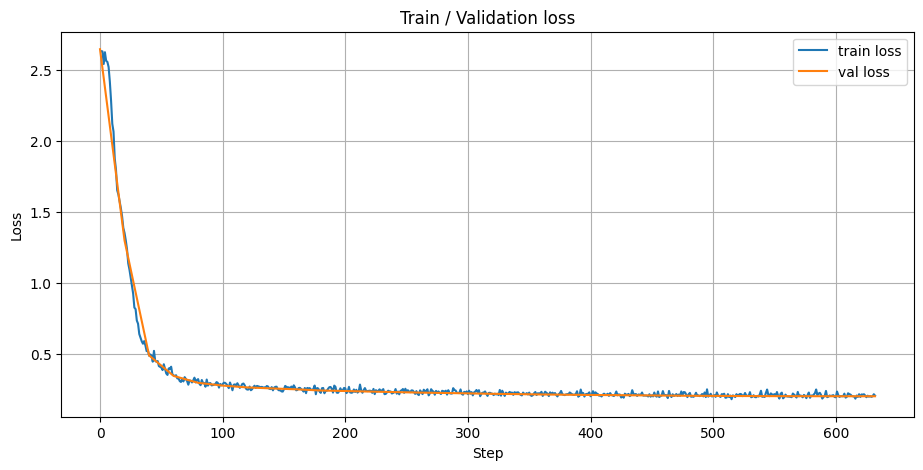

In [13]:
plt.figure(figsize=(11, 5))
plt.plot(train_logs["step"], train_logs["loss"], label="train loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="val loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Train / Validation loss")
plt.legend()
plt.grid(True)
plt.show()

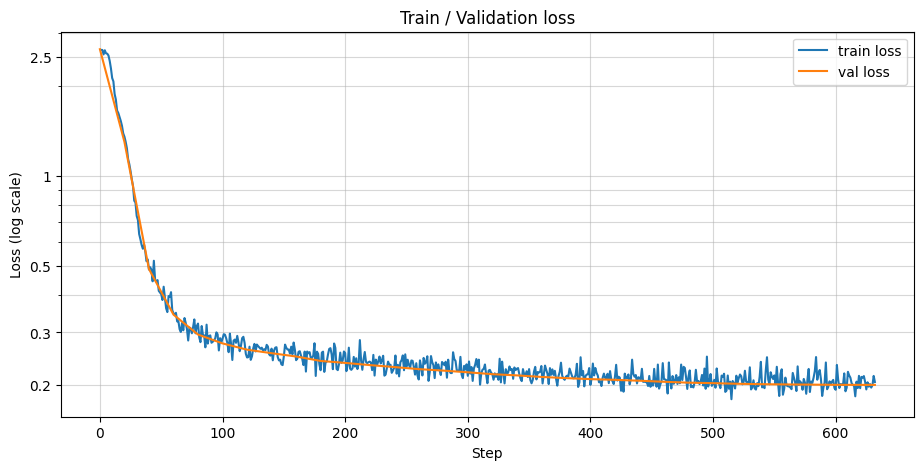

In [23]:
plt.figure(figsize=(11, 5))
plt.plot(train_logs["step"], train_logs["loss"], label="train loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="val loss")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.title("Train / Validation loss")
yticks = [0.2, 0.3, 0.5, 1, 2.5]
plt.yticks(yticks, [str(y) for y in yticks])
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()


Save and push to Hub.

In [24]:
trainer.model.save_pretrained(output_dir)
student_tokenizer.save_pretrained(output_dir)

('./gemma3_1b_countdown_verified_10k/tokenizer_config.json',
 './gemma3_1b_countdown_verified_10k/chat_template.jinja',
 './gemma3_1b_countdown_verified_10k/tokenizer.json')

In [27]:
trainer.model.push_to_hub(hub_model_id)
student_tokenizer.push_to_hub(hub_model_id)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/pymlex/gemma3-1b-countdown/commit/93cde00d7093b481aaea415bacc745da13201877', commit_message='Upload tokenizer', commit_description='', oid='93cde00d7093b481aaea415bacc745da13201877', pr_url=None, repo_url=RepoUrl('https://huggingface.co/pymlex/gemma3-1b-countdown', endpoint='https://huggingface.co', repo_type='model', repo_id='pymlex/gemma3-1b-countdown'), pr_revision=None, pr_num=None)

## Evaluation

Helper functions. We simply use the `eval` function for expression evaluation.

In [ ]:
def parse_answer(text):
    match = re.search(r"<answer>\s*(.*?)\s*</answer>", text, re.S)
    if match is None:
        return text.strip()
    return match.group(1).strip()

def split_prompt_and_target(text):
    prompt_text = re.split(r"<start_of_turn>model\s*\n", text, maxsplit=1)[0]
    match = re.search(r"equals\s+(-?\d+)\.", prompt_text)
    target = int(match.group(1))
    return prompt_text, target

def generate_student_batch_from_prompts(model, tokenizer, prompts, max_new_tokens=850):
    encodings = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True
    ).to(model.device)

    print(
        f"Eval batch start | batch={len(prompts)} | "
        f"prompt_tokens={encodings['input_ids'].shape[1]} | {gpu_status_line()}"
    )

    with torch.inference_mode():
        generated = model.generate(
            **encodings,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.95,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    prompt_lengths = encodings["attention_mask"].sum(dim=1).tolist()
    outputs = []

    for i, prompt_length in enumerate(prompt_lengths):
        completion_ids = generated[i, prompt_length:]
        completion = tokenizer.decode(completion_ids, skip_special_tokens=True).strip()
        outputs.append(completion)

    print(f"Eval batch done | {gpu_status_line()}")

    return outputs

def score_predictions(predictions, targets):
    correct = 0

    for pred, target in zip(predictions, targets):
        expr = parse_answer(pred).strip().strip("\n")
        if "=" in expr:
            expr = expr.split("=")[0].strip()

        try:
            value = eval(expr)
            if value == target:
                correct += 1
        except Exception:
            pass

    return correct, len(targets)

In [41]:
val_texts = val_ds["text"]
val_limit = len(val_texts)

val_prompts = []
val_targets = []

for text in val_texts[:val_limit]:
    prompt_text, target = split_prompt_and_target(text)
    val_prompts.append(prompt_text)
    val_targets.append(target)

val_predictions = []
batch_prompts = []
batch_size = 20

for prompt in tqdm(val_prompts, total=len(val_prompts)):
    batch_prompts.append(prompt)

    if len(batch_prompts) == batch_size:
        completions = generate_student_batch_from_prompts(
            student_model,
            student_tokenizer,
            batch_prompts,
        )
        val_predictions.extend(completions)
        batch_prompts = []

if len(batch_prompts) > 0:
    completions = generate_student_batch_from_prompts(
        student_model,
        student_tokenizer,
        batch_prompts,
    )
    val_predictions.extend(completions)

correct, total = score_predictions(val_predictions, val_targets)
accuracy = correct / total
print(f"Validation accuracy: {accuracy:.4f} ({correct}/{total})")

  0%|          | 0/1064 [00:00<?, ?it/s]

Eval batch start | batch=200 | prompt_tokens=128 | GPU=0% | VRAM=23847/32607 MB
Eval batch done | GPU=92% | VRAM=23847/32607 MB
Eval batch start | batch=200 | prompt_tokens=128 | GPU=92% | VRAM=23847/32607 MB
Eval batch done | GPU=91% | VRAM=23847/32607 MB
Eval batch start | batch=200 | prompt_tokens=128 | GPU=91% | VRAM=23847/32607 MB
Eval batch done | GPU=92% | VRAM=23847/32607 MB
Eval batch start | batch=200 | prompt_tokens=129 | GPU=92% | VRAM=23847/32607 MB
Eval batch done | GPU=91% | VRAM=23847/32607 MB
Eval batch start | batch=200 | prompt_tokens=128 | GPU=91% | VRAM=23847/32607 MB
Eval batch done | GPU=92% | VRAM=23847/32607 MB
Eval batch start | batch=64 | prompt_tokens=128 | GPU=92% | VRAM=23847/32607 MB
Eval batch done | GPU=84% | VRAM=23847/32607 MB
Validation accuracy: 0.8412 (895/1064)


## Inference

In [ ]:
student_tokenizer = AutoTokenizer.from_pretrained("pymlex/gemma3-1b-countdown")
if student_tokenizer.pad_token is None:
    student_tokenizer.pad_token = student_tokenizer.eos_token
student_tokenizer.padding_side = "left"

base_student_model = AutoModelForCausalLM.from_pretrained(
    student_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if bf16 else torch.float16
)

student_model = PeftModel.from_pretrained(base_student_model, "pymlex/gemma3-1b-countdown")
student_model.eval()

In [ ]:
def generate_student_batch(model, tokenizer, batch_messages):
    prompts = [
        tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
        for messages in batch_messages
    ]

    encodings = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True
    ).to(model.device)

    print(
        f"Inference batch start | batch={len(batch_messages)} | "
        f"prompt_tokens={encodings['input_ids'].shape[1]} | {gpu_status_line()}"
    )

    with torch.inference_mode():
        generated = model.generate(
            **encodings,
            max_new_tokens=850,
            do_sample=True,
            temperature=0.7,
            top_p=0.95,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    prompt_lengths = encodings["attention_mask"].sum(dim=1).tolist()
    outputs = []

    for i, prompt_length in enumerate(prompt_lengths):
        completion_ids = generated[i, prompt_length:]
        completion = tokenizer.decode(completion_ids, skip_special_tokens=True).strip()
        outputs.append(completion)

    print(f"Inference batch done | {gpu_status_line()}")

    return outputs

def parse_nums(value):
    if isinstance(value, str):
        return json.loads(value)
    return value
    

def build_test_messages_from_row(row):
    nums = parse_nums(row["nums"])
    target = row["target"]
    return [
        {
            "role": "system",
            "content": "You are a helpful assistant. You first think about the reasoning process in the mind and then provide the user with the answer."
        },
        {
            "role": "user",
            "content": f"Using the numbers {nums}, create an equation that equals {target}. You can use basic arithmetic operations (+, -, *, /) and each number can only be used once. Show your work in <think> </think> tags. And return the final equation and answer in <answer> </answer> tags, for example <answer> (1 + 2) / 3 = 1 </answer>."
        }
    ]

def predict_equations(model, tokenizer, nums_list, targets, batch_size=4, max_new_tokens=256):
    rows = [{"nums": nums, "target": target} for nums, target in zip(nums_list, targets)]
    batch_messages = []
    outputs = []

    for row in rows:
        batch_messages.append(build_test_messages_from_row(row))

        if len(batch_messages) == batch_size:
            completions = generate_student_batch(
                model,
                tokenizer,
                batch_messages,
                max_new_tokens
            )
            outputs.extend([parse_answer(text) for text in completions])
            batch_messages = []

    if len(batch_messages) > 0:
        completions = generate_student_batch(
            model,
            tokenizer,
            batch_messages,
            max_new_tokens
        )
        outputs.extend([parse_answer(text) for text in completions])

    return outputs

In [50]:
sample_nums = [[78, 46, 93], [24, 2, 5]]
sample_targets = [61, 31]

sample_predictions = predict_equations(
    student_model,
    student_tokenizer,
    sample_nums,
    sample_targets,
    batch_size=2,
    max_new_tokens=850
)

for pred in sample_predictions:
    print(pred)
    print('-' * 100)

Inference batch start | batch=2 | prompt_tokens=127 | GPU=0% | VRAM=23847/32607 MB
Inference batch done | GPU=78% | VRAM=23847/32607 MB
(93 + 46) - 78 = 61
----------------------------------------------------------------------------------------------------
24 + 2 + 5 = 31
----------------------------------------------------------------------------------------------------
